# Supervised Machine Learning

In [61]:
import pandas as pd # -> Module yang digunaakn untuk analisis data, editing dataframe
import numpy as np # -> Module yang digunakan untuk operasi matematika
import matplotlib.pyplot as plt # -> Module yang digunakan untuk melakukan visualisasi data
import seaborn as sns # -> Module yang digunakan untuk melakukan visualisasi data

movies_data = pd.read_csv('data/movies_metadata.csv')
rating = pd.read_csv('data/ratings_small.csv')

<Axes: xlabel='rating', ylabel='Count'>

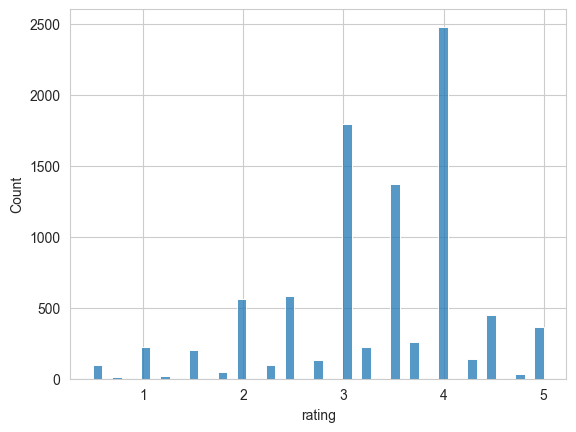

In [62]:
rating_movies = rating.groupby('movieId', as_index=False)['rating'].median()
sns.histplot(data = rating_movies, x = 'rating')

In [99]:
profitable_movies = movies_data
new_df = profitable_movies.merge(rating_movies, left_on = 'id', right_on = 'movieId', how = 'inner')

new_df.select_dtypes(include = "number")

def select_columns(df: pd.DataFrame, features: list, target: list = 'rating'):
    x = df[features]
    y = (df[target] >= 3).astype(int)

    return x, y

In [100]:
from sklearn.model_selection import train_test_split

In [101]:
features = ["budget", "popularity", "runtime", "vote_average"]
x, y = select_columns(new_df, features = features)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()

minmax.fit(x_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [102]:
minmax.fit(x_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [103]:
x_train_scaled = minmax.transform(x_train)
x_test_scaled = minmax.transform(x_test)

In [104]:
def scaling(df, scaler):

    df["runtime"] = df["runtime"].div(60)
    scaled_array = scaler.transform(df)
    scaled_df = pd.DataFrame(scaled_array, columns = scaler.get_feature_names_out())

    return scaled_df

In [105]:
x_train_scaled = scaling(x_train, minmax)
x_test_scaled = scaling(x_test, minmax)

In [106]:
x_train_scaled

,budget,popularity,runtime,vote_average
0,0.000000,0.004792,0.003958,0.68
1,0.247368,0.180899,0.005208,0.76
2,0.000000,0.055144,0.005677,0.71
3,0.000000,0.029227,0.005365,0.61
4,0.000000,0.036867,0.007344,0.78
...,...,...,...,...
1976,0.000000,0.012892,0.007083,0.66
1977,0.000000,0.059516,0.004844,0.63
1978,0.007895,0.043208,0.006927,0.73
1979,0.000421,0.031439,0.004375,0.75


In [107]:
x_test_scaled

,budget,popularity,runtime,vote_average
0,0.000000,0.000773,0.004375,0.00
1,0.006579,0.082517,0.005313,0.71
2,0.210526,0.060481,0.006667,0.63
3,0.000000,0.022602,0.004688,0.69
4,0.013002,0.034645,0.006250,0.76
...,...,...,...,...
845,0.131579,0.064438,0.005573,0.59
846,0.047368,0.017484,0.005521,0.53
847,0.108684,0.085573,0.005104,0.63
848,0.052632,0.075278,0.007031,0.72


In [108]:
x_test.iloc[0]

budget          0.000000
popularity      0.108898
runtime         1.400000
vote_average    0.000000
Name: 2087, dtype: float64

In [133]:
from sklearn.tree import DecisionTreeClassifier

In [134]:
dt = DecisionTreeClassifier()

In [140]:
dt.fit(x_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [150]:
y_test_pred_dt = dt.predict(x_test_scaled)

In [151]:
pd.crosstab(y_test, y_test_pred_dt)

col_0,0,1
rating,,
0,29,126
1,141,554


In [153]:
pd.crosstab(y_test, y_test_pred_dt)

col_0,0,1
rating,,
0,29,126
1,141,554


In [146]:
x_train_scaled.isna().sum()

budget          0
popularity      0
runtime         3
vote_average    0
dtype: int64